Loaded 1 polarisation CSV(s) and 0 PDG CSV(s) from E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\SOK1
    Label      xMax      yMax  x_flipped  y_flipped  x_min_flipped  \
0   16448  0.536132  0.844134  -0.536132   0.844134       0.844134   
2   26512  0.832742 -0.553662   0.832742   0.553662      -0.553662   
7    6804  0.936323 -0.351141   0.936323   0.351141      -0.351141   
8    4500  0.066451  0.997790  -0.066451   0.997790       0.997790   
14  13500  0.584536  0.811368  -0.584536   0.811368       0.811368   
17  27666  0.999674  0.025526  -0.999674   0.025526       0.025526   
23   6682  0.928718 -0.370787   0.928718   0.370787      -0.370787   
24  22042  0.988028  0.154272  -0.988028   0.154272       0.154272   
25   8282  0.853796  0.520608  -0.853796   0.520608       0.520608   
27  20022  0.379589  0.925155  -0.379589   0.925155       0.925155   
28   3342  0.901540 -0.432696   0.901540   0.432696      -0.432696   
33  55769  0.497443  0.8674

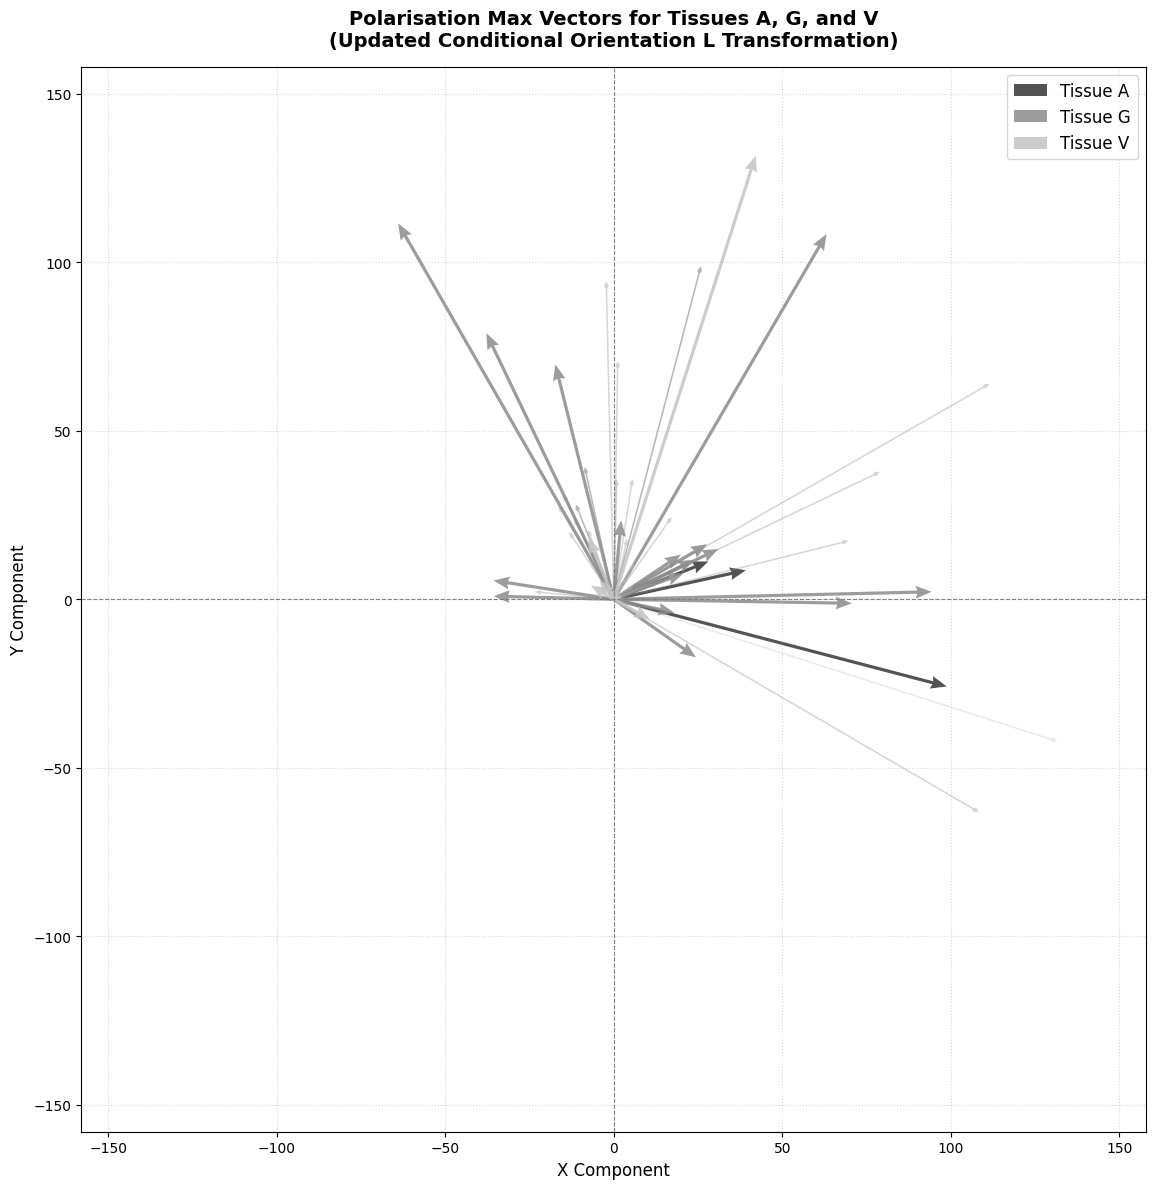

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# Folder containing the CSV files
csv_folder = Path(r"E:\Work\SOKs\TIFFS_publication\Fig SX_emergence-cellular\polarisation\script\SOK1")

# Find polarisation and PDG files separately
polarisation_files = sorted(csv_folder.glob("polarisation*.csv"))
pdg_files = sorted(csv_folder.glob("PDGs*.csv"))
if len(polarisation_files) == 0:
    raise FileNotFoundError(f"No polarisation CSV files found in {csv_folder}")

polar_df = pd.concat((pd.read_csv(csv_file) for csv_file in polarisation_files), ignore_index=True)
print(f"Loaded {len(polarisation_files)} polarisation CSV(s) and {len(pdg_files)} PDG CSV(s) from {csv_folder}")

# Filter for tissues A, G, and V
polar_df = polar_df[polar_df['Tissue'].isin(['A', 'G', 'V', 'CE'])].copy()

# Keep the same filtered dataframe name used later
filtered_df = polar_df

# Set up distinct colors for each tissue type
colors = {'A': "#353535", 'G': "#8b8b8b", 'V': "#c4c4c4", 'CE': "#8b8b8b"}

# Define the precise conditional transformation logic for Orientation 'L'
def apply_flip_rules(row):
    x = row['xMax']
    y = row['yMax']
    
    if row['Orientation'] == 'L':
        if x > 0 and y > 0:
            x = -x  # Both positive -> only make X max negative
        elif x < 0:
            x = -x  # Negative X -> make it positive (leaves negative Y alone if both were negative)
        elif y < 0:
            y = -y  # Positive X and Negative Y -> make Y positive
            
    return pd.Series([x, y])

# Apply the transformation rules for x/y max
filtered_df[['x_flipped', 'y_flipped']] = filtered_df.apply(apply_flip_rules, axis=1)

# Also compute flipped values for xMin/yMin (if present) and scaled vectors
if 'xMin' in filtered_df.columns and 'yMin' in filtered_df.columns:
    def apply_flip_rules_min(row):
        x = row['xMin']
        y = row['yMin']
        if row['Orientation'] == 'L':
            if x > 0 and y > 0:
                x = -x
            elif x < 0:
                x = -x
            elif y < 0:
                y = -y
        return pd.Series([x, y])

    filtered_df[['x_min_flipped', 'y_min_flipped']] = filtered_df.apply(apply_flip_rules_min, axis=1)
    filtered_df['U_min'] = filtered_df['x_min_flipped'] * filtered_df['signalMax']
    filtered_df['V_min'] = filtered_df['y_min_flipped'] * filtered_df['signalMax']
else:
    filtered_df['x_min_flipped'] = np.nan
    filtered_df['y_min_flipped'] = np.nan
    filtered_df['U_min'] = 0
    filtered_df['V_min'] = 0

# Calculate U and V components for the max vectors scaled by signalMax
filtered_df['U'] = filtered_df['x_flipped'] * filtered_df['signalMax']
filtered_df['V'] = filtered_df['y_flipped'] * filtered_df['signalMax']

# Inspect the changes for Orientation 'L' to see which rows are affected by the new rule
print(filtered_df[filtered_df['Orientation'] == 'L'][['Label', 'xMax', 'yMax', 'x_flipped', 'y_flipped', 'x_min_flipped', 'y_min_flipped', 'signalMax']])

fig, ax = plt.subplots(figsize=(12, 12))

# Plot each group separately (plot max vectors prominently and min vectors as thinner/softer)
for tissue, group in filtered_df.groupby('Tissue'):
    # max vectors
    ax.quiver(np.zeros(len(group)), np.zeros(len(group)), 
              group['U'], group['V'], 
              angles='xy', scale_units='xy', scale=1, 
              color=colors[tissue], alpha=0.85, label=f"Tissue {tissue}",
              width=0.003, headwidth=4, headlength=5)

    # min vectors (if present) — use thinner arrows and lower alpha
    if (group['U_min'].abs().sum() != 0) or (group['V_min'].abs().sum() != 0):
        ax.quiver(np.zeros(len(group)), np.zeros(len(group)),
                  group['U_min'], group['V_min'],
                  angles='xy', scale_units='xy', scale=1,
                  color=colors[tissue], alpha=0.35,
                  width=0.0015, headwidth=3, headlength=3)

    # Add labels at the end of max arrows
    for idx, row in group.iterrows():
        magnitude = np.hypot(row['U'], row['V'])
        if magnitude > 0:
            dx = (row['U'] / magnitude) * 2.5
            dy = (row['V'] / magnitude) * 2.5
        else:
            dx, dy = 0, 0
        # optional label placement (commented out)
        #ax.text(row['U'] + dx, row['V'] + dy, str(int(row['Label'])),
        #        color=colors[tissue], fontsize=9, fontweight='bold',
        #        ha='center', va='center')

# Add origin axes lines
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# Styling
ax.set_aspect('equal')
max_limit = max(filtered_df['U'].abs().max(), filtered_df['V'].abs().max()) * 1.2
ax.set_xlim(-max_limit, max_limit)
ax.set_ylim(-max_limit, max_limit)

ax.set_title("Polarisation Max Vectors for Tissues A, G, and V\n(Updated Conditional Orientation L Transformation)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("X Component", fontsize=12)
ax.set_ylabel("Y Component", fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig("polarisation_vectors_final.png", dpi=300)
print("Plot successfully regenerated.")

Labeled polar plot saved successfully.

Correlation between PDG angle and polarisation angle:
  Pearson r = 0.241, p = 0.1841
  Spearman rho = nan, p = nan
  Linear regression: slope = nan, intercept = nan
  R^2 = nan, p = nan


C:\Users\mjcpi\AppData\Local\Temp\ipykernel_32280\1394710336.py:59: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  linreg = stats.linregress(merged['pdg_angle'], merged['deviation_degrees'])


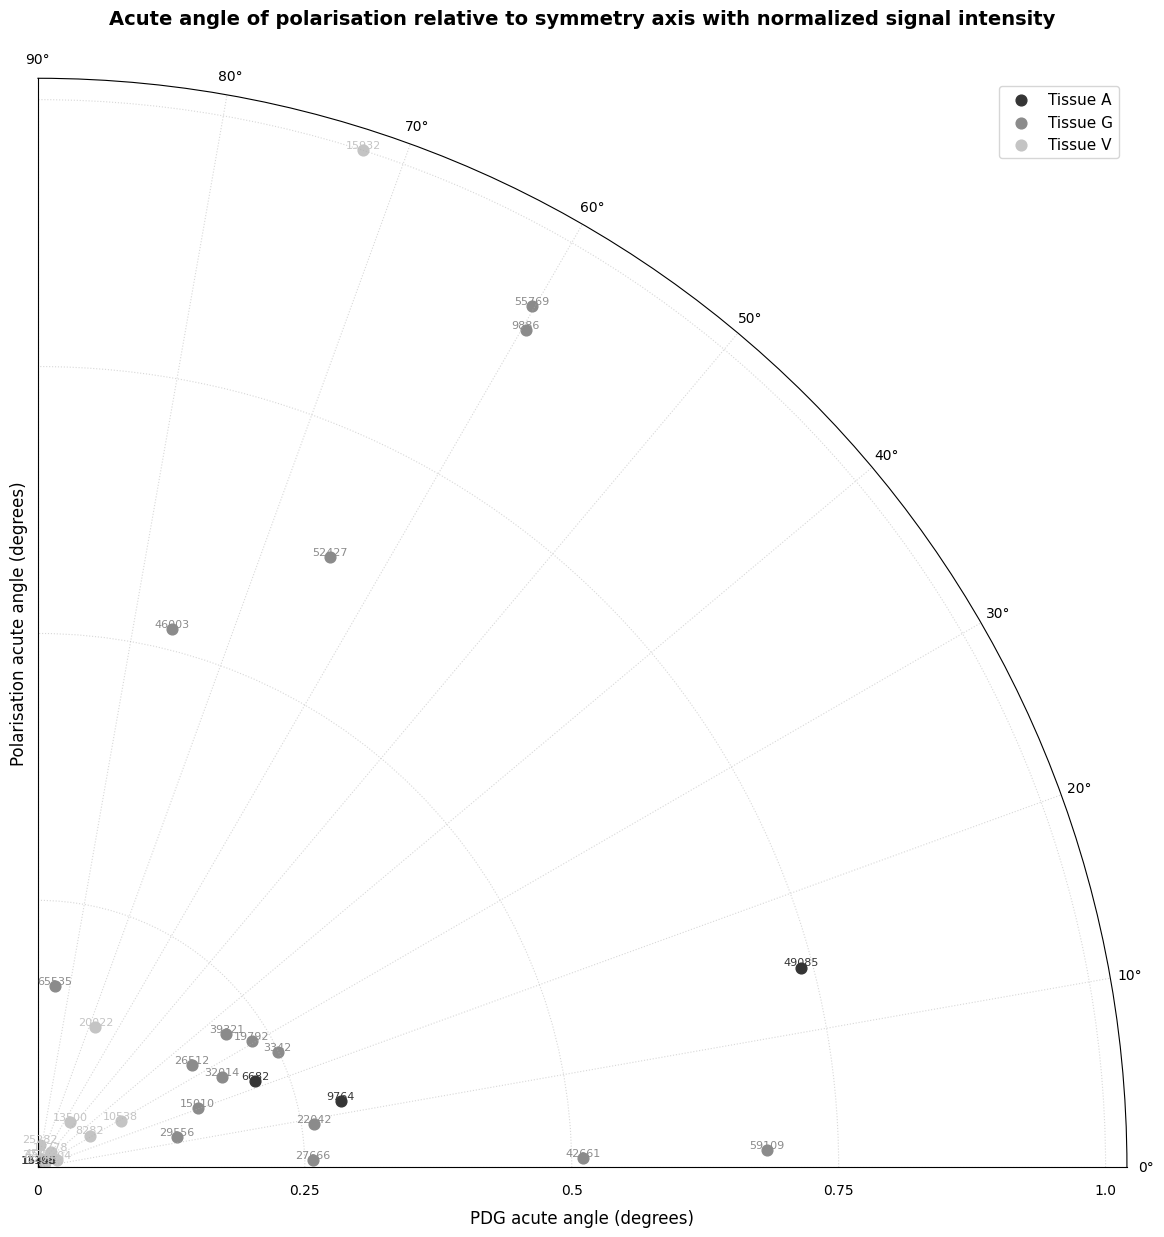

In [ ]:
# Calculate the deviation from the horizontal line (radians) for max vectors
filtered_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(filtered_df['y_flipped']), np.abs(filtered_df['x_flipped'])))
filtered_df['theta'] = np.radians(filtered_df['deviation_degrees'])

# If min vectors are present, calculate their acute deviation and theta too
if 'y_min_flipped' in filtered_df.columns and 'x_min_flipped' in filtered_df.columns:
    filtered_df['deviation_degrees_min'] = np.degrees(np.arctan2(np.abs(filtered_df['y_min_flipped']), np.abs(filtered_df['x_min_flipped'])))
    filtered_df['theta_min'] = np.radians(filtered_df['deviation_degrees_min'])
else:
    filtered_df['deviation_degrees_min'] = np.nan
    filtered_df['theta_min'] = np.nan

# Normalize signal intensity to 0-1 range
filtered_df['r'] = filtered_df['signalMax'] / filtered_df['signalMax'].max()

# Define Plot
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='polar')

# Plot each tissue: max vectors as full points, min vectors as faint/x markers
for tissue, group in filtered_df.groupby('Tissue'):
    ax.scatter(group['theta'], group['r'], c=colors[tissue], label=f"Tissue {tissue}", alpha=1, s=60)

    # plot min-vector acute angles if available
    if group['theta_min'].notna().any():
        ax.scatter(group['theta_min'], group['r'], c=colors[tissue], label=f"Tissue {tissue} (min)", alpha=0.35, s=30, marker='x')

    # Add text labels for each max-vector point
    for _, row in group.iterrows():
        ax.text(row['theta'], row['r'], str(int(row['Label'])), 
                fontsize=8, color=colors[tissue], ha='center', va='bottom')

# Set theta limits to 0-90 degrees (0 to pi/2)
ax.set_thetamin(0)
ax.set_thetamax(90)
ax.set_theta_zero_location("E") # Horizontal line at 0 degrees
ax.set_theta_direction(1) # Counter-clockwise

# Set radial limits and labels (normalized 0-1)
ax.set_ylim(0, 1.02)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1.0'], fontsize=10)
ax.tick_params(axis='y', pad=8)

# Show normalized signal intensity on the X and Y axis labels
ax.set_xlabel('Normalized signal intensity', labelpad=25)

# Title and Labels
plt.title("Acute angle of polarisation relative to symmetry axis with normalized signal intensity", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))

plt.tight_layout()
plt.savefig("polarisation_polar_plot_labeled.svg", format='svg')
print("Labeled polar plot saved successfully.")

# -------------------------------------------------------------------------
# Correlation between PDG angle and polarisation angle for matching labels
# -------------------------------------------------------------------------

pdg_df['pdg_angle'] = np.degrees(np.arctan2(np.abs(pdg_df['yMax']), np.abs(pdg_df['xMax'])))

# Merge polarisation and PDG angles by label and tissue
polar_angles = filtered_df[['Label', 'Tissue', 'deviation_degrees']].copy()
merged = pd.merge(polar_angles, pdg_df[['Label', 'Tissue', 'pdg_angle']], on=['Label', 'Tissue'], how='inner')

#if merged.empty:
#    raise ValueError('No matching labels found between polarisation and PDG datasets.')

#pearson_r, pearson_p = stats.pearsonr(merged['pdg_angle'], merged['deviation_degrees'])
spearman_r, spearman_p = stats.spearmanr(merged['pdg_angle'], merged['deviation_degrees'])
linreg = stats.linregress(merged['pdg_angle'], merged['deviation_degrees'])
r_squared = linreg.rvalue ** 2

print('\nCorrelation between PDG angle and polarisation angle:')
print(f"  Pearson r = {pearson_r:.3f}, p = {pearson_p:.4g}")
print(f"  Spearman rho = {spearman_r:.3f}, p = {spearman_p:.4g}")
print(f"  Linear regression: slope = {linreg.slope:.4f}, intercept = {linreg.intercept:.3f}")
print(f"  R^2 = {r_squared:.3f}, p = {linreg.pvalue:.4g}")

#m, b = np.polyfit(merged['pdg_angle'], merged['deviation_degrees'], 1)
line_x = np.linspace(merged['pdg_angle'].min(), merged['pdg_angle'].max(), 100)
#ax.plot(line_x, m * line_x + b, color='black', linewidth=1.5, label=f"Linear fit: y={m:.2f}x+{b:.2f}")

ax.set_xlabel('PDG acute angle (degrees)', fontsize=12)
ax.set_ylabel('Polarisation acute angle (degrees)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

Weighted acute-angle comparison by tissue:
  A: mean=15.591°, 95% CI=(13.818, 16.849)
  G: mean=39.465°, 95% CI=(29.870, 56.745)
  V: mean=65.899°, 95% CI=(70.010, 72.253)

Pairwise weighted bootstrap comparisons:
  A vs G: delta=-23.875°, p_boot=0.0004
  A vs V: delta=-50.308°, p_boot=0.0000
  G vs V: delta=-26.433°, p_boot=0.0000
Weighted mean acute angle plot with bootstrap statistical results saved successfully.


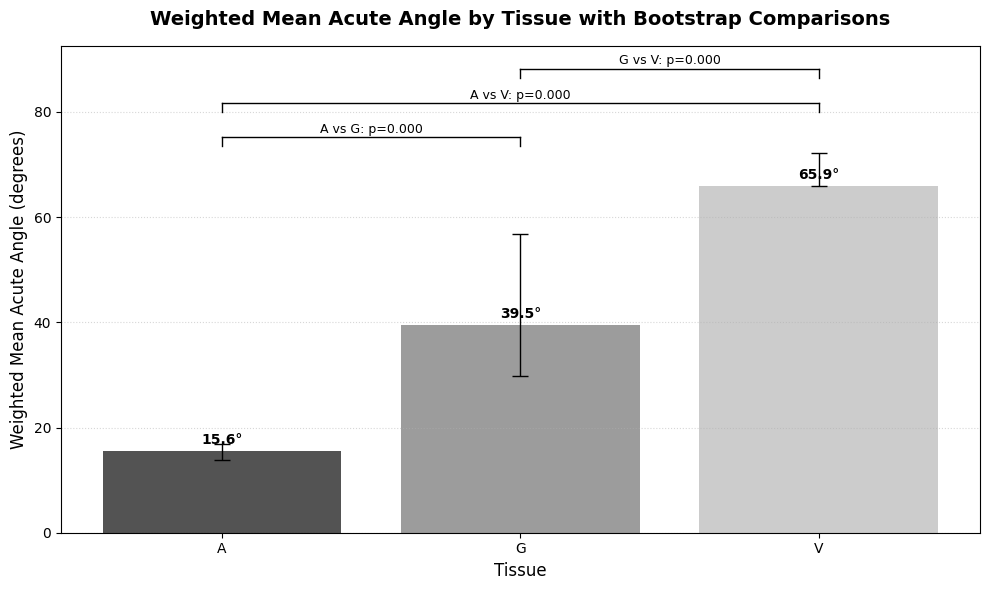

In [55]:
from itertools import combinations

# Weighted acute-angle summary per tissue
weighted_means = filtered_df.groupby('Tissue').apply(
    lambda g: np.average(g['deviation_degrees'], weights=g['signalMax'])
).reset_index(name='mean_acute_angle')

# Bootstrap weighted means within each tissue
np.random.seed(0)
n_boot = 5000
bootstrap = {}
cis = {}
for tissue, group in filtered_df.groupby('Tissue'):
    angles = group['deviation_degrees'].values
    weights = group['signalMax'].values
    if len(angles) == 0:
        raise ValueError(f'No data for tissue {tissue}')
    if weights.sum() <= 0:
        raise ValueError(f'Zero total weight for tissue {tissue}')

    probs = weights / weights.sum()
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(len(angles), size=len(angles), replace=True, p=probs)
        boot_means[i] = np.average(angles[idx], weights=weights[idx])

    bootstrap[tissue] = boot_means
    cis[tissue] = np.percentile(boot_means, [2.5, 97.5])

weighted_means['ci_lo'] = weighted_means['Tissue'].map(lambda t: cis[t][0])
weighted_means['ci_hi'] = weighted_means['Tissue'].map(lambda t: cis[t][1])
weighted_means['ci_err_lo'] = np.maximum(weighted_means['mean_acute_angle'] - weighted_means['ci_lo'], 0)
weighted_means['ci_err_hi'] = np.maximum(weighted_means['ci_hi'] - weighted_means['mean_acute_angle'], 0)

# Pairwise bootstrap comparison of weighted means
pairwise_results = []
for a, b in combinations(weighted_means['Tissue'], 2):
    diffs = bootstrap[a] - bootstrap[b]
    p_boot = 2 * min(np.mean(diffs >= 0), np.mean(diffs <= 0))
    p_boot = min(p_boot, 1.0)
    a_mean = weighted_means.loc[weighted_means['Tissue'] == a, 'mean_acute_angle'].iloc[0]
    b_mean = weighted_means.loc[weighted_means['Tissue'] == b, 'mean_acute_angle'].iloc[0]
    delta = float(a_mean - b_mean)
    pairwise_results.append((a, b, p_boot, delta))

# Print weighted inference summary
print('Weighted acute-angle comparison by tissue:')
for _, row in weighted_means.iterrows():
    print(f"  {row['Tissue']}: mean={row['mean_acute_angle']:.3f}°, 95% CI=({row['ci_lo']:.3f}, {row['ci_hi']:.3f})")
print('\nPairwise weighted bootstrap comparisons:')
for a, b, p_boot, delta in pairwise_results:
    print(f'  {a} vs {b}: delta={delta:.3f}°, p_boot={p_boot:.4f}')

# Plot weighted means with bootstrap CIs and pairwise results
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(weighted_means))
bar_colors = [colors[t] for t in weighted_means['Tissue']]

ax.bar(x, weighted_means['mean_acute_angle'], color=bar_colors, alpha=0.85,
       yerr=np.vstack([weighted_means['ci_err_lo'], weighted_means['ci_err_hi']]),
       capsize=6, error_kw=dict(ecolor='black', lw=1))
ax.set_xticks(x)
ax.set_xticklabels(weighted_means['Tissue'])

for idx, row in weighted_means.iterrows():
    ax.text(idx, row['mean_acute_angle'] + 0.8,
            f"{row['mean_acute_angle']:.1f}°", ha='center', va='bottom', fontsize=10, fontweight='bold')

base = weighted_means['ci_hi'].max() * 1.04
step = weighted_means['ci_hi'].max() * 0.09
for i, (a, b, p_boot, delta) in enumerate(pairwise_results):
    left = weighted_means.index[weighted_means['Tissue'] == a][0]
    right = weighted_means.index[weighted_means['Tissue'] == b][0]
    y = base + i * step
    ax.plot([left, right], [y, y], color='black', lw=1)
    ax.plot([left, left], [y, y - step * 0.25], color='black', lw=1)
    ax.plot([right, right], [y, y - step * 0.25], color='black', lw=1)
    ax.text((left + right) / 2, y + step * 0.05,
            f"{a} vs {b}: p={p_boot:.3f}",
            ha='center', va='bottom', fontsize=9)

ax.set_title('Weighted Mean Acute Angle by Tissue with Bootstrap Comparisons', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tissue', fontsize=12)
ax.set_ylabel('Weighted Mean Acute Angle (degrees)', fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('weighted_mean_acute_angle_with_stats.svg', format='svg')
print('Weighted mean acute angle plot with bootstrap statistical results saved successfully.')

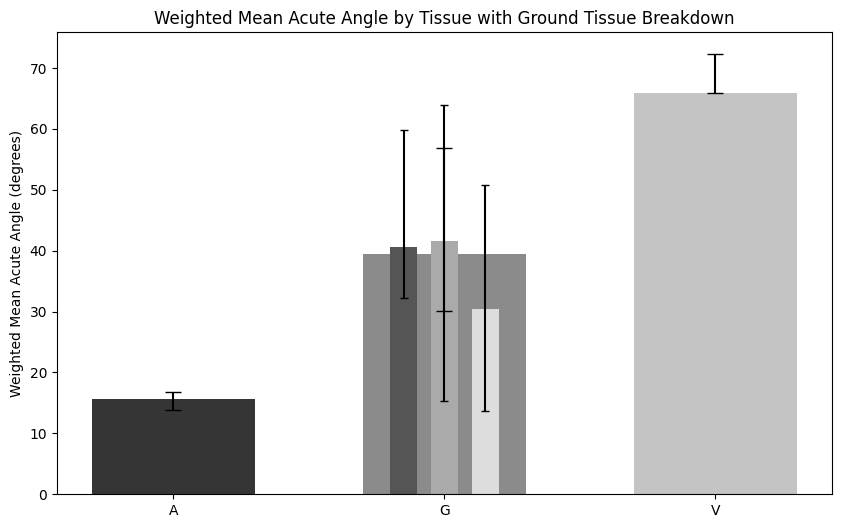

In [56]:

polar_df[['x_flipped', 'y_flipped']] = polar_df.apply(apply_flip_rules, axis=1)

# Also compute flipped min vectors for polar_df if present
if 'xMin' in polar_df.columns and 'yMin' in polar_df.columns:
    def apply_flip_rules_min(row):
        x = row['xMin']
        y = row['yMin']
        if row['Orientation'] == 'L':
            if x > 0 and y > 0:
                x = -x
            elif x < 0:
                x = -x
            elif y < 0:
                y = -y
        return pd.Series([x, y])

    polar_df[['x_min_flipped', 'y_min_flipped']] = polar_df.apply(apply_flip_rules_min, axis=1)
    polar_df['U_min'] = polar_df['x_min_flipped'] * polar_df['signalMax']
    polar_df['V_min'] = polar_df['y_min_flipped'] * polar_df['signalMax']
else:
    polar_df['x_min_flipped'] = np.nan
    polar_df['y_min_flipped'] = np.nan
    polar_df['U_min'] = 0
    polar_df['V_min'] = 0

polar_df['deviation_degrees'] = np.degrees(np.arctan2(np.abs(polar_df['y_flipped']), np.abs(polar_df['x_flipped'])))

# Stats function
def get_weighted_stats(df, n_boot=5000):
    angles = df['deviation_degrees'].values
    weights = df['signalMax'].values
    if len(angles) == 0:
        return 0, 0, 0
    probs = weights / weights.sum()
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.random.choice(len(angles), size=len(angles), replace=True, p=probs)
        boot_means[i] = np.average(angles[idx], weights=weights[idx])
    
    mean_val = np.average(angles, weights=weights)
    ci = np.percentile(boot_means, [2.5, 97.5])
    return mean_val, ci[0], ci[1]

# Main groups
groups = ['A', 'G', 'V']
main_data = {}
for t in groups:
    subset = polar_df[polar_df['Tissue'] == t]
    mean, lo, hi = get_weighted_stats(subset)
    main_data[t] = {'mean': mean, 'lo': lo, 'hi': hi}

# G sub-groups
g_subset = polar_df[polar_df['Tissue'] == 'G']
g_subgroups = ['V', 'CE', 'E']
sub_data = {}
for sg in g_subgroups:
    subset = g_subset[g_subset['Specific tissue'] == sg]
    mean, lo, hi = get_weighted_stats(subset)
    sub_data[sg] = {'mean': mean, 'lo': lo, 'hi': hi}

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(groups))
colors_map = {'A': "#353535", 'G': "#8b8b8b", 'V': "#c4c4c4"}
bar_colors = [colors_map[t] for t in groups]

# Plot main bars
means = [main_data[t]['mean'] for t in groups]
# Create the error array (2 rows: row 0 is lower error, row 1 is upper error)
# Ensure errors are positive and reflect the distance from the mean
err_lower = np.array([max(main_data[t]['mean'] - main_data[t]['lo'], 0) for t in groups])
err_upper = np.array([main_data[t]['hi'] - main_data[t]['mean'] for t in groups])

# Combine into a (2, N) array for yerr
err_combined = np.vstack([err_lower, err_upper])

# Plotting
ax.bar(x_pos, means, color=bar_colors, yerr=err_combined, capsize=6, label='Main Tissues', width=0.6)

# Overlay sub-bars on G (index 1)
sub_x_offsets = [-0.15, 0, 0.15]
sub_labels = ['V', 'CE', 'E']
sub_colors = ['#555555', '#aaaaaa', '#dddddd']

for i, sg in enumerate(sub_labels):
    mean = sub_data[sg]['mean']
    lo = sub_data[sg]['lo']
    hi = sub_data[sg]['hi']
    
    # Ensure error values are non-negative
    e_low = max(mean - lo, 0)
    e_high = max(hi - mean, 0)
    
    ax.bar(x_pos[1] + sub_x_offsets[i], mean, 
           color=sub_colors[i], 
           yerr=np.array([[e_low], [e_high]]), 
           capsize=3, width=0.1, label=f"G-{sg}")

ax.set_xticks(x_pos)
ax.set_xticklabels(groups)
ax.set_ylabel('Weighted Mean Acute Angle (degrees)')
ax.set_title('Weighted Mean Acute Angle by Tissue with Ground Tissue Breakdown')
plt.savefig('tissue_and_g_breakdown.png')